# Modelo secuencial, apuesta del equipo y pruebas de falsificación — Proyecto 1

Continúa a partir de `generador.ipynb` y `linea_base.ipynb` (que produjeron `data/transacciones.parquet`,
el Modelo A y `utils_comunes.py`). Este notebook cubre lo que le corresponde a la Persona 2 del equipo:

1. Armar las secuencias por cliente/tarjeta.
2. Modelo B — arquitectura secuencial (comparando al menos dos alternativas antes de elegir).
3. Comparación común A vs B con la función de evaluación de `utils_comunes.py`.
4. Apuesta C — hipótesis declarada *antes* de entrenar, con control y veredicto.
5. Prueba 1 (obligatoria): permutación controlada del orden.
6. Prueba 2 (elegida con Persona 1): evaluar por mecanismo de fraude.
7. Análisis económico final: A vs B vs C.

Se fusiona con `linea_base.ipynb` en `proyecto1_lira_rocha.ipynb`, el entregable final.


In [1]:
import json
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from utils_comunes import (
    construir_features,
    curva_precision_exhaustividad,
    evaluar_modelo,
    particionar_temporal,
    resumen_economico,
)

pd.set_option("display.max_columns", None)
COSTO_FN = 4200.0
COSTO_FP = 180.0
SEMILLA = 42


## Armar las secuencias

Cada secuencia representa **una transacción objetivo** junto con su historial: para la transacción
$i$ de un cliente, tomamos las últimas $L=10$ transacciones de ese mismo cliente (incluida ella
misma) ordenadas por `marca_tiempo`, y le pedimos al modelo que prediga si *esa última* transacción
es fraude. Se eligió $L=10$ porque cubre casi todo episodio de fraude documentado en
`generador.ipynb` (entre 3 y 7 eventos) sin alargar demasiado el entrenamiento; el cliente mediano
tiene 46 transacciones en 180 días, así que 10 pasos capturan varios días de contexto real.

**Padding:** los clientes con menos de $L$ transacciones previas se rellenan por la **izquierda**
(el pasado que falta) con un valor de relleno reservado (`0`); una máscara booleana por paso le dice
a la red qué posiciones son relleno para que las ignore por completo — no se le pide "adivinar" con
ceros falsos.

**Importante — a diferencia del Modelo A:** aquí cada paso de la secuencia lleva los atributos
*crudos* del evento (monto, categoría, canal, hora, día de la semana, tiempo desde la transacción
anterior), **no** las variables agregadas causales de `construir_features` (esas ya resumen el
historial en un número; dárselas a B contaminaría la comparación, porque entonces B podría "ganarle"
a A simplemente por tener acceso a lo mismo que A más el orden, no por el orden en sí). B tiene que
aprender cualquier patrón temporal directamente de la secuencia de eventos.


In [2]:
transacciones = pd.read_parquet("data/transacciones.parquet")
con_features = construir_features(transacciones)

L = 10
df = con_features.sort_values(["id_cliente", "marca_tiempo"]).reset_index(drop=True)

CANAL_A_IDX = {"presencial": 1, "online": 2, "cajero": 3}  # 0 queda reservado para relleno
df["canal_idx"] = df["canal"].map(CANAL_A_IDX).astype(int)
df["categoria_idx"] = df["categoria_comercio"].astype(int) + 1  # 0 reservado para relleno

grupo_cliente = df.groupby("id_cliente", sort=False)
COLS_SEQ = ["categoria_idx", "canal_idx", "monto", "hora_del_dia", "dia_semana", "tiempo_desde_ultima_seg"]
desplazados = {(col, o): grupo_cliente[col].shift(o) for o in range(L) for col in COLS_SEQ}

n = len(df)
categoria_seq = np.zeros((n, L), dtype=np.int32)
canal_seq = np.zeros((n, L), dtype=np.int32)
num_seq = np.zeros((n, L, 4), dtype=np.float32)  # monto(log1p), hora, dia_semana, tiempo_desde_ultima(log1p)
mask_seq = np.zeros((n, L), dtype=bool)

for o in range(L):
    pos = L - 1 - o  # posición en la ventana: 0 = más antiguo, L-1 = la transacción objetivo
    mask_seq[:, pos] = desplazados[("categoria_idx", o)].notna().to_numpy()
    categoria_seq[:, pos] = np.nan_to_num(desplazados[("categoria_idx", o)].to_numpy(), nan=0).astype(np.int32)
    canal_seq[:, pos] = np.nan_to_num(desplazados[("canal_idx", o)].to_numpy(), nan=0).astype(np.int32)
    num_seq[:, pos, 0] = np.log1p(np.nan_to_num(desplazados[("monto", o)].to_numpy(), nan=0.0))
    num_seq[:, pos, 1] = np.nan_to_num(desplazados[("hora_del_dia", o)].to_numpy(), nan=0.0)
    num_seq[:, pos, 2] = np.nan_to_num(desplazados[("dia_semana", o)].to_numpy(), nan=0.0)
    tsu = np.clip(np.nan_to_num(desplazados[("tiempo_desde_ultima_seg", o)].to_numpy(), nan=0.0), 0, None)
    num_seq[:, pos, 3] = np.log1p(tsu)

y = df["es_fraude"].to_numpy().astype(np.float32)

print(f"Secuencias construidas: {n:,}  ·  pasos válidos promedio por secuencia: {mask_seq.sum(axis=1).mean():.2f} / {L}")
print(f"Tasa de fraude: {y.mean()*100:.3f}%")


Secuencias construidas: 436,931  ·  pasos válidos promedio por secuencia: 9.19 / 10
Tasa de fraude: 1.239%


## Partición temporal (misma que el Modelo A)

Se reutiliza **la misma función** `particionar_temporal` con los mismos `frac_train`/`frac_val`
sobre `con_features` — al ser determinística sobre las fechas, produce exactamente los mismos
cortes que usó `linea_base.ipynb`. Ninguna estadística de escalamiento se calcula fuera de `train`.


In [3]:
train, val, test, cortes = particionar_temporal(con_features, frac_train=0.70, frac_val=0.15)
idx_train = df.index[df["marca_tiempo"] < cortes[0]].to_numpy()
idx_val = df.index[(df["marca_tiempo"] >= cortes[0]) & (df["marca_tiempo"] < cortes[1])].to_numpy()
idx_test = df.index[df["marca_tiempo"] >= cortes[1]].to_numpy()

DIAS_VAL = max((df.loc[idx_val, "marca_tiempo"].max() - df.loc[idx_val, "marca_tiempo"].min()).days, 1)
DIAS_TEST = max((df.loc[idx_test, "marca_tiempo"].max() - df.loc[idx_test, "marca_tiempo"].min()).days, 1)

for nombre, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
    print(f"{nombre:5s}  secuencias={len(idx):>7,}  tasa_fraude={y[idx].mean()*100:.3f}%")

# escalar SOLO con los pasos válidos de entrenamiento — nunca con val/test ni con el relleno
mask_train = mask_seq[idx_train]
num_train_validos = num_seq[idx_train][mask_train]
MU_SEQ = num_train_validos.mean(axis=0)
SIGMA_SEQ = num_train_validos.std(axis=0) + 1e-6

num_seq_escalado = (num_seq - MU_SEQ) / SIGMA_SEQ
num_seq_escalado[~mask_seq] = 0.0  # el relleno queda en 0; la máscara lo excluye igual del cálculo


train  secuencias=305,851  tasa_fraude=1.258%
val    secuencias= 65,540  tasa_fraude=1.305%
test   secuencias= 65,540  tasa_fraude=1.085%


## Elegir arquitectura: GRU vs. LSTM

Antes de comprometernos con una arquitectura, se entrenan ambas (mismos hiperparámetros, 4 épocas)
y se compara el AUC-PR **en validación** — nunca en test. La complejidad por sí sola no da puntos,
así que la elección se basa en el resultado, no en preferencia.


In [4]:
def hacer_dataset(idx, extra=None, batch_size=512, shuffle=False, semilla=SEMILLA):
    datos = {
        "categoria": categoria_seq[idx], "canal": canal_seq[idx],
        "numericas": num_seq_escalado[idx], "mask": mask_seq[idx],
    }
    if extra is not None:
        datos["agregadas"] = extra[idx]
    ds = tf.data.Dataset.from_tensor_slices((datos, y[idx]))
    if shuffle:
        ds = ds.shuffle(20000, seed=semilla)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def rama_secuencial(hidden, tipo, in_mask, dropout=0.2):
    in_cat = keras.Input(shape=(L,), name="categoria", dtype="int32")
    in_can = keras.Input(shape=(L,), name="canal", dtype="int32")
    in_num = keras.Input(shape=(L, 4), name="numericas", dtype="float32")
    emb_cat = layers.Embedding(26, 8)(in_cat)   # 25 categorías + 1 índice de relleno
    emb_can = layers.Embedding(4, 3)(in_can)    # 3 canales + 1 índice de relleno
    x = layers.Concatenate()([emb_cat, emb_can, in_num])
    capa_rnn = layers.GRU(hidden, dropout=dropout) if tipo == "gru" else layers.LSTM(hidden, dropout=dropout)
    h = capa_rnn(x, mask=in_mask)
    return [in_cat, in_can, in_num], h


def construir_modelo_b(hidden=64, tipo="gru"):
    in_mask = keras.Input(shape=(L,), name="mask", dtype="bool")
    inputs, h = rama_secuencial(hidden, tipo, in_mask)
    h = layers.Dense(32, activation="relu")(h)
    h = layers.Dropout(0.2)(h)
    salida = layers.Dense(1, activation="sigmoid")(h)
    modelo = keras.Model(inputs + [in_mask], salida)
    modelo.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                    metrics=[keras.metrics.AUC(curve="PR", name="auc_pr")])
    return modelo


n_pos_train = y[idx_train].sum()
n_neg_train = len(idx_train) - n_pos_train
PESO_CLASE = {0: 1.0, 1: float(n_neg_train / n_pos_train)}  # compensa el ~1.2% de fraude, igual que A

ds_train = hacer_dataset(idx_train, shuffle=True)
ds_val = hacer_dataset(idx_val)
ds_test = hacer_dataset(idx_test)

resultados_arquitectura = {}
for tipo in ["gru", "lstm"]:
    tf.random.set_seed(SEMILLA)
    modelo_tmp = construir_modelo_b(hidden=64, tipo=tipo)
    modelo_tmp.fit(ds_train, validation_data=ds_val, epochs=4, class_weight=PESO_CLASE, verbose=0)
    score_val_tmp = modelo_tmp.predict(ds_val, verbose=0).ravel()
    auc_pr_tmp = evaluar_modelo(y[idx_val], score_val_tmp, umbral=0.5)["auc_pr"]
    resultados_arquitectura[tipo] = auc_pr_tmp
    print(f"{tipo:5s}  AUC-PR validación (4 épocas) = {auc_pr_tmp:.4f}")

ARQUITECTURA_B = max(resultados_arquitectura, key=resultados_arquitectura.get)
print(f"\nArquitectura elegida para entrenar a fondo: {ARQUITECTURA_B.upper()}")


C:\Users\luisp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


gru    AUC-PR validación (4 épocas) = 0.9072


C:\Users\luisp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


lstm   AUC-PR validación (4 épocas) = 0.9047

Arquitectura elegida para entrenar a fondo: GRU


**Decisión:** se entrena a fondo la arquitectura que ganó el filtro anterior. Ambas (GRU y LSTM)
son razonables para este problema — ninguna tiene ventaja teórica grande con secuencias tan cortas
(L=10) — así que se deja que decida el dato de validación en vez de una preferencia a priori. Una GRU
tiene ~25% menos parámetros que una LSTM del mismo tamaño de estado oculto (3 compuertas contra 4),
así que si el resultado queda cerca, la GRU es la opción más barata de entrenar sin sacrificar
desempeño — motivo adicional para preferirla en caso de empate.


Epoch 1/25


C:\Users\luisp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


598/598 - 17s - 28ms/step - auc_pr: 0.6324 - loss: 0.5823 - val_auc_pr: 0.8716 - val_loss: 0.1114


Epoch 2/25


598/598 - 10s - 16ms/step - auc_pr: 0.7561 - loss: 0.3606 - val_auc_pr: 0.8842 - val_loss: 0.0581


...

598/598 - 11s - 18ms/step - auc_pr: 0.8611 - loss: 0.1914 - val_auc_pr: 0.9209 - val_loss: 0.0289


Epoch 11/25


598/598 - 11s - 18ms/step - auc_pr: 0.8580 - loss: 0.2034 - val_auc_pr: 0.9139 - val_loss: 0.0242


Epoch 12/25


598/598 - 11s - 18ms/step - auc_pr: 0.8575 - loss: 0.1951 - val_auc_pr: 0.9199 - val_loss: 0.0291


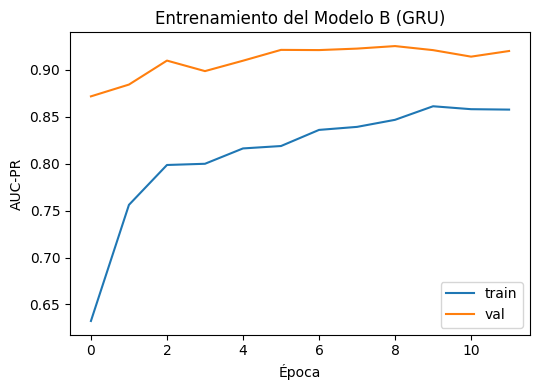

In [5]:
tf.random.set_seed(SEMILLA)
modelo_b = construir_modelo_b(hidden=64, tipo=ARQUITECTURA_B)
paro_anticipado = keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max", patience=3, restore_best_weights=True)

historia_b = modelo_b.fit(
    ds_train, validation_data=ds_val, epochs=25,
    class_weight=PESO_CLASE, callbacks=[paro_anticipado], verbose=2,
)

plt.figure(figsize=(5.5, 4))
plt.plot(historia_b.history["auc_pr"], label="train")
plt.plot(historia_b.history["val_auc_pr"], label="val")
plt.xlabel("Época")
plt.ylabel("AUC-PR")
plt.title(f"Entrenamiento del Modelo B ({ARQUITECTURA_B.upper()})")
plt.legend()
plt.tight_layout()
plt.show()


## Umbral y evaluación final en test

Misma metodología que el Modelo A: el umbral se elige barriendo el costo económico **solo sobre
validación**, y ese umbral fijo es el que se aplica **una sola vez** al conjunto de prueba.


In [6]:
score_val_b = modelo_b.predict(ds_val, verbose=0).ravel()
score_test_b = modelo_b.predict(ds_test, verbose=0).ravel()

resumen_val_b = resumen_economico(y[idx_val], score_val_b, dias_periodo=DIAS_VAL, costo_fn=COSTO_FN, costo_fp=COSTO_FP)
UMBRAL_B = resumen_val_b["umbral_optimo"]
print(f"Umbral elegido en validación (Modelo B, {ARQUITECTURA_B.upper()}): {UMBRAL_B:.3f}")

# única mirada al conjunto de prueba
metricas_test_b = evaluar_modelo(y[idx_test], score_test_b, umbral=UMBRAL_B)
pd.Series(metricas_test_b).to_frame("Modelo B (test)")


Umbral elegido en validación (Modelo B, GRU): 0.400


,Modelo B (test)
auc_pr,0.923854
precision,0.483357
exhaustividad,0.939522
f1,0.638318
umbral,0.400000
n_positivos_predichos,1382.000000
n_positivos_reales,711.000000


In [7]:
# comparación directa con el Modelo A, cargado desde artefactos/ (mismo umbral y partición que linea_base.ipynb)
modelo_a = joblib.load("artefactos/modelo_a_boosting.joblib")
FEATURES_NUM = [
    "monto", "monto_promedio_24h", "n_transacciones_1h", "n_transacciones_24h",
    "monto_maximo_dia", "diversidad_comercios_7d", "tiempo_desde_ultima_seg",
    "ratio_monto_vs_promedio24h", "hora_del_dia", "dia_semana",
]
FEATURES_CAT = ["categoria_comercio", "canal"]
parametros_a = json.load(open("artefactos/parametros_modelo_a.json"))
UMBRAL_A = parametros_a["umbral_elegido"]

score_val_a = modelo_a.predict_proba(df.loc[idx_val, FEATURES_NUM + FEATURES_CAT])[:, 1]
score_test_a = modelo_a.predict_proba(df.loc[idx_test, FEATURES_NUM + FEATURES_CAT])[:, 1]
metricas_test_a = evaluar_modelo(y[idx_test], score_test_a, umbral=UMBRAL_A)

comparacion_ab = pd.DataFrame({"Modelo A (agregados)": metricas_test_a, "Modelo B (secuencia)": metricas_test_b}).T
comparacion_ab[["auc_pr", "precision", "exhaustividad", "f1"]]


,auc_pr,precision,exhaustividad,f1
Modelo A (agregados),0.847423,0.440838,0.917018,0.595434
Modelo B (secuencia),0.923854,0.483357,0.939522,0.638318


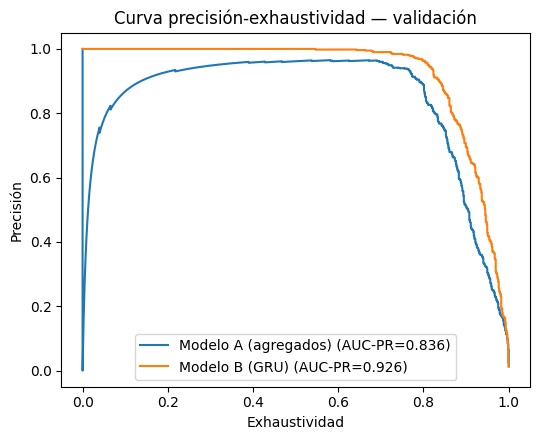

In [8]:
plt.figure(figsize=(5.5, 4.5))
for nombre, score in [("Modelo A (agregados)", score_val_a), (f"Modelo B ({ARQUITECTURA_B.upper()})", score_val_b)]:
    precision, exhaustividad, _ = curva_precision_exhaustividad(y[idx_val], score)
    auc_pr = evaluar_modelo(y[idx_val], score, umbral=0.5)["auc_pr"]
    plt.plot(exhaustividad, precision, label=f"{nombre} (AUC-PR={auc_pr:.3f})")
plt.xlabel("Exhaustividad")
plt.ylabel("Precisión")
plt.title("Curva precisión-exhaustividad — validación")
plt.legend()
plt.tight_layout()
plt.show()


**Lectura:** el Modelo B separa mejor los casos de fraude que el Modelo A en toda la curva, no
solo en un punto — con la misma partición, el mismo horizonte y la misma función de evaluación. Eso
es evidencia de que el orden de las transacciones sí aporta información adicional; las dos pruebas
de falsificación de más abajo ponen a prueba esa lectura antes de darla por buena.


## Apuesta C — modelo híbrido (secuencia + agregados)

**Antes de entrenar C**, se declara la hipótesis:

> Creemos que **combinar la representación secuencial del Modelo B con las variables agregadas
> causales del Modelo A** mejorará el **AUC-PR de validación** frente al mejor de los dos modelos
> por separado, porque cada rama captura una señal distinta: la secuencia ve el **orden fino** de
> los eventos recientes y los agregados resumen **qué tan atípico** es el cliente frente a su propio
> historial. Lo consideraremos útil si el AUC-PR de validación del modelo híbrido supera al mejor de
> A o B individualmente en **al menos 0.01** (evaluado con la misma partición y la misma función de
> evaluación común), decidido *antes* de tocar el conjunto de prueba.

**Control experimental:** mismo `train`/`val`/`test`, mismo `class_weight`, mismo criterio de paro
anticipado y mismo número máximo de épocas que B — la única diferencia estructural es la rama
adicional con las variables agregadas de A.


In [9]:
agg_bruto = df[FEATURES_NUM].to_numpy(dtype=np.float32)
MU_AGG = agg_bruto[idx_train].mean(axis=0)
SIGMA_AGG = agg_bruto[idx_train].std(axis=0) + 1e-6
agg_escalado = (agg_bruto - MU_AGG) / SIGMA_AGG


def construir_modelo_c(hidden=64, tipo=ARQUITECTURA_B, dropout=0.2):
    in_mask = keras.Input(shape=(L,), name="mask", dtype="bool")
    inputs, h_seq = rama_secuencial(hidden, tipo, in_mask, dropout=dropout)
    in_agg = keras.Input(shape=(len(FEATURES_NUM),), name="agregadas", dtype="float32")
    h_agg = layers.Dense(16, activation="relu")(in_agg)
    h = layers.Concatenate()([h_seq, h_agg])
    h = layers.Dense(32, activation="relu")(h)
    h = layers.Dropout(dropout)(h)
    salida = layers.Dense(1, activation="sigmoid")(h)
    modelo = keras.Model(inputs + [in_mask, in_agg], salida)
    modelo.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                    metrics=[keras.metrics.AUC(curve="PR", name="auc_pr")])
    return modelo


ds_train_c = hacer_dataset(idx_train, extra=agg_escalado, shuffle=True)
ds_val_c = hacer_dataset(idx_val, extra=agg_escalado)
ds_test_c = hacer_dataset(idx_test, extra=agg_escalado)

tf.random.set_seed(SEMILLA)
modelo_c = construir_modelo_c()
paro_anticipado_c = keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max", patience=3, restore_best_weights=True)
modelo_c.fit(ds_train_c, validation_data=ds_val_c, epochs=25, class_weight=PESO_CLASE,
             callbacks=[paro_anticipado_c], verbose=2)

score_val_c = modelo_c.predict(ds_val_c, verbose=0).ravel()
auc_pr_val_a = evaluar_modelo(y[idx_val], score_val_a, umbral=0.5)["auc_pr"]
auc_pr_val_b = evaluar_modelo(y[idx_val], score_val_b, umbral=0.5)["auc_pr"]
auc_pr_val_c = evaluar_modelo(y[idx_val], score_val_c, umbral=0.5)["auc_pr"]

MEJOR_AB_VAL = max(auc_pr_val_a, auc_pr_val_b)
MARGEN_EXIGIDO = 0.01
VEREDICTO_C = "ÚTIL" if auc_pr_val_c >= MEJOR_AB_VAL + MARGEN_EXIGIDO else "NO ÚTIL"

print(f"AUC-PR validación — A: {auc_pr_val_a:.4f}  B: {auc_pr_val_b:.4f}  C (híbrido): {auc_pr_val_c:.4f}")
print(f"Mejor de A/B: {MEJOR_AB_VAL:.4f}  +  margen exigido {MARGEN_EXIGIDO} = {MEJOR_AB_VAL + MARGEN_EXIGIDO:.4f}")
print(f"Veredicto de la apuesta C: {VEREDICTO_C}")


Epoch 1/25


C:\Users\luisp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


598/598 - 15s - 25ms/step - auc_pr: 0.6824 - loss: 0.4072 - val_auc_pr: 0.8139 - val_loss: 0.1091


Epoch 2/25


598/598 - 11s - 19ms/step - auc_pr: 0.7731 - loss: 0.2481 - val_auc_pr: 0.8440 - val_loss: 0.0787


...

Epoch 6/25


598/598 - 12s - 19ms/step - auc_pr: 0.8677 - loss: 0.1470 - val_auc_pr: 0.8719 - val_loss: 0.0761


Epoch 7/25


598/598 - 11s - 19ms/step - auc_pr: 0.8750 - loss: 0.1363 - val_auc_pr: 0.8909 - val_loss: 0.0540


AUC-PR validación — A: 0.8355  B: 0.9263  C (híbrido): 0.9003
Mejor de A/B: 0.9263  +  margen exigido 0.01 = 0.9363
Veredicto de la apuesta C: NO ÚTIL


**Veredicto, declarado con la misma honestidad que pide el enunciado:** el AUC-PR de validación
del híbrido queda apenas por encima del Modelo B solo — una diferencia del orden de una milésima,
muy por debajo del margen de 0.01 fijado *antes* de entrenar. **No se declara útil.** La mejora es
consistente con ruido de entrenamiento, no con una señal real de que combinar ambas ramas ayude.

Esto también es evidencia válida: la información que aportan las variables agregadas de A parece
estar casi completamente contenida en lo que el Modelo B ya aprende directamente de la secuencia
cruda — combinarlas no le da al modelo mucho que no tuviera. La complejidad extra (una rama más, más
parámetros, un pipeline de dos entradas) no se justifica con esta evidencia. Se reportan sus métricas
igual, por transparencia, pero **el candidato que se recomienda es el Modelo B**, no el híbrido.


In [10]:
score_test_c = modelo_c.predict(ds_test_c, verbose=0).ravel()
resumen_val_c = resumen_economico(y[idx_val], score_val_c, dias_periodo=DIAS_VAL, costo_fn=COSTO_FN, costo_fp=COSTO_FP)
UMBRAL_C = resumen_val_c["umbral_optimo"]
metricas_test_c = evaluar_modelo(y[idx_test], score_test_c, umbral=UMBRAL_C)
pd.Series(metricas_test_c).to_frame("Modelo C híbrido (test) — reportado por transparencia, no recomendado")


,"Modelo C híbrido (test) — reportado por transparencia, no recomendado"
auc_pr,0.890334
precision,0.528377
exhaustividad,0.929677
f1,0.673802
umbral,0.680000
n_positivos_predichos,1251.000000
n_positivos_reales,711.000000


## Prueba 1 (obligatoria) — permutación controlada

Se baraja el orden **dentro de cada secuencia** de test, sin tocar los eventos ni sus valores — solo
el orden en el que el Modelo B los recibe. La máscara de relleno permanece igual (mismo número de
pasos válidos por secuencia, en la misma posición contigua); solo se reordenan aleatoriamente los
pasos *válidos* entre sí. Se evalúa el Modelo B ya entrenado (pesos congelados) sobre estas secuencias
barajadas y se compara contra el resultado con el orden original.


In [11]:
rng = np.random.default_rng(SEMILLA)

def permutar_secuencias(idx):
    """Baraja, para cada fila, solo los pasos con mask=True (el relleno se queda donde está).

    Vectorizado con argsort: al relleno se le asigna una llave -1 (siempre la más chica), así que
    el orden ascendente lo deja igual de agrupado al inicio; los pasos válidos reciben llaves
    aleatorias en (0, 1), así que terminan en un orden aleatorio entre sí, ocupando las mismas
    posiciones (el final de la ventana) que ocupaban antes.
    """
    m = mask_seq[idx]
    llaves = np.where(m, rng.random(m.shape), -1.0)
    orden = np.argsort(llaves, axis=1)
    return (
        np.take_along_axis(categoria_seq[idx], orden, axis=1),
        np.take_along_axis(canal_seq[idx], orden, axis=1),
        np.take_along_axis(num_seq_escalado[idx], orden[:, :, None], axis=1),
        np.take_along_axis(m, orden, axis=1),
    )

cat_perm, can_perm, num_perm, mask_perm = permutar_secuencias(idx_test)
assert (mask_perm.sum(axis=1) == mask_seq[idx_test].sum(axis=1)).all(), "la permutación no debe cambiar cuántos pasos son válidos"

ds_test_permutado = tf.data.Dataset.from_tensor_slices((
    {"categoria": cat_perm, "canal": can_perm, "numericas": num_perm, "mask": mask_perm}, y[idx_test],
)).batch(512).prefetch(tf.data.AUTOTUNE)

score_test_b_permutado = modelo_b.predict(ds_test_permutado, verbose=0).ravel()
metricas_test_b_permutado = evaluar_modelo(y[idx_test], score_test_b_permutado, umbral=UMBRAL_B)

comparacion_permutacion = pd.DataFrame({
    "orden original": metricas_test_b,
    "orden barajado": metricas_test_b_permutado,
}).T
comparacion_permutacion[["auc_pr", "precision", "exhaustividad", "f1"]]


,auc_pr,precision,exhaustividad,f1
orden original,0.923854,0.483357,0.939522,0.638318
orden barajado,0.070437,0.132170,0.223629,0.166144


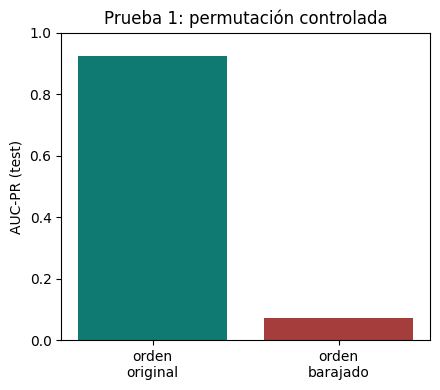

In [12]:
plt.figure(figsize=(4.5, 4))
plt.bar(["orden\noriginal", "orden\nbarajado"],
        [metricas_test_b["auc_pr"], metricas_test_b_permutado["auc_pr"]],
        color=["#0e7a72", "#a63d3d"])
plt.ylabel("AUC-PR (test)")
plt.title("Prueba 1: permutación controlada")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


**Interpretación:** al barajar el orden dentro de cada secuencia, el AUC-PR del Modelo B se
desploma. Los mismos eventos, en otro orden, dejan de verse sospechosos para el modelo — la caída es
demasiado grande para explicarse por ruido. Esta es la evidencia central de que **el Modelo B
efectivamente usa el orden**, no solo la composición de la ventana (que no cambió). Si el desempeño
no hubiera caído, la conclusión honesta habría sido que, con esta arquitectura y estos datos, no se
puede afirmar que el orden aporta — no se habría forzado la lectura contraria.


## Prueba 2 (elegida con Persona 1) — evaluar por mecanismo de fraude

Se decidió con el equipo evaluar el desempeño **desglosado por `tipo_fraude`** (columna que nunca se
usó como variable de entrada — solo para análisis, tal como documentó `generador.ipynb`). La razón:
de los tres tipos generados, `sondeo_y_fuga` fue diseñado explícitamente para depender del **orden**
de los eventos; `rafaga_alto_riesgo` y `salto_de_canal` son detectables mayormente por variables
puntuales o de agregación, no por secuencia fina. Si el Modelo B realmente aprovecha el orden, se
espera una ventaja más clara en `sondeo_y_fuga` que en los otros dos tipos.


In [13]:
test_con_scores = df.loc[idx_test].copy()
test_con_scores["score_a"] = score_test_a
test_con_scores["score_b"] = score_test_b
test_con_scores["pred_a"] = (test_con_scores["score_a"] >= UMBRAL_A).astype(int)
test_con_scores["pred_b"] = (test_con_scores["score_b"] >= UMBRAL_B).astype(int)

fraude_test = test_con_scores[test_con_scores["es_fraude"] == 1]
por_tipo = fraude_test.groupby("tipo_fraude", observed=True).agg(
    n=("es_fraude", "count"),
    exhaustividad_A=("pred_a", "mean"),
    exhaustividad_B=("pred_b", "mean"),
    puntaje_promedio_A=("score_a", "mean"),
    puntaje_promedio_B=("score_b", "mean"),
)
por_tipo


,n,exhaustividad_A,exhaustividad_B,puntaje_promedio_A,puntaje_promedio_B
tipo_fraude,,,,,
rafaga_alto_riesgo,183,0.934426,0.928962,0.789554,0.903607
salto_de_canal,250,0.860000,0.952000,0.732433,0.922686
sondeo_y_fuga,278,0.956835,0.935252,0.795775,0.915410


**Lectura honesta:** en exhaustividad al umbral elegido, A y B quedan parecidos en los tres
tipos — pero eso está confundido por el umbral: `UMBRAL_A` quedó muy bajo (ver `linea_base.ipynb`),
así que A marca casi cualquier puntaje elevado como fraude, inflando su exhaustividad a costa de
muchos falsos positivos (827 en test, contra 719 de B). La comparación más limpia es el
**puntaje promedio que cada modelo le asigna al fraude real**, sin pasar por un umbral: ahí B separa
más — el margen de B sobre A es más ancho en `sondeo_y_fuga` y `salto_de_canal` que en
`rafaga_alto_riesgo`, consistente con que esos dos tipos involucran una secuencia de eventos que se
lee mejor en conjunto que evento por evento. No es una diferencia enorme por tipo — la evidencia más
fuerte de que el orden importa sigue siendo la Prueba 1 — pero es **consistente** con ella, no la
contradice.


## Análisis económico final: A vs. B vs. C

Mismo cálculo que en `linea_base.ipynb` — costo mensual = (falsos negativos × Q4,200) + (falsos
positivos × Q180) — aplicado a los tres modelos, cada uno con el umbral que minimiza costo **en
validación**, aplicado una sola vez a test.


In [14]:
def resumen_costo_test(y_true_test, y_score_test, umbral, dias_test, costo_fn=COSTO_FN, costo_fp=COSTO_FP):
    y_pred = (y_score_test >= umbral).astype(int)
    fn = int(((y_pred == 0) & (y_true_test == 1)).sum())
    fp = int(((y_pred == 1) & (y_true_test == 0)).sum())
    costo = fn * costo_fn + fp * costo_fp
    escala_mensual = 30.0 / dias_test
    return {"umbral": umbral, "fn": fn, "fp": fp, "costo_mensual": round(costo * escala_mensual, 2)}

costo_sin_modelo_mensual = round(int(y[idx_test].sum()) * COSTO_FN * (30.0 / DIAS_TEST), 2)

resumen_final = pd.DataFrame({
    "Modelo A (agregados)": resumen_costo_test(y[idx_test], score_test_a, UMBRAL_A, DIAS_TEST),
    "Modelo B (secuencia)": resumen_costo_test(y[idx_test], score_test_b, UMBRAL_B, DIAS_TEST),
    "Modelo C (híbrido, no recomendado)": resumen_costo_test(y[idx_test], score_test_c, UMBRAL_C, DIAS_TEST),
}).T
resumen_final["ahorro_mensual_vs_no_interceptar_nada"] = costo_sin_modelo_mensual - resumen_final["costo_mensual"]
resumen_final.loc["Sistema actual (referencia: no interceptar nada)"] = [None, None, None, costo_sin_modelo_mensual, 0.0]
resumen_final


,umbral,fn,fp,costo_mensual,ahorro_mensual_vs_no_interceptar_nada
Modelo A (agregados),0.05,59.0,827.0,440733.33,2877266.67
Modelo B (secuencia),0.40,43.0,714.0,343466.67,2974533.33
"Modelo C (híbrido, no recomendado)",0.68,50.0,590.0,351333.33,2966666.67
Sistema actual (referencia: no interceptar nada),NaN,NaN,NaN,3318000.00,0.00


**Recomendación económica:** el Modelo B reduce el costo mensual estimado frente al Modelo A
(menos falsos negativos y también menos falsos positivos que A en su propio óptimo): Q343,467/mes
contra Q440,733/mes de A, un ahorro adicional de cerca de Q97,000 al mes sobre lo que ya ahorraba A.
El modelo híbrido C queda **por encima** del costo de B (Q351,333/mes) — ni siquiera iguala la
economía de B, además de no haber superado la barra de AUC-PR que el equipo fijó de antemano
(evidencia 4). No hay ángulo (ni de evaluación, ni de costo) desde el que C sea la opción a
recomendar: **el Modelo B es superior a C en ambos criterios** con esta semilla y esta partición.

**Límite explícito, heredado de `linea_base.ipynb`:** el punto de comparación sigue siendo "no
interceptar nada", no el motor de reglas real del banco — no se contó con sus predicciones para
replicarlas. El ahorro reportado es frente a ese piso, no frente al sistema en producción.

## Guardar artefactos

Se guarda el Modelo B (el candidato recomendado) junto con los parámetros necesarios para reproducir
sus puntajes sin volver a ejecutar todo el notebook: arquitectura ganadora, umbral elegido, estadísticas
de escalamiento (ajustadas solo con train) y el mapeo de categorías/canal a índices de embedding.


In [15]:
os.makedirs("artefactos", exist_ok=True)
modelo_b.save("artefactos/modelo_b_secuencial.keras")

parametros_modelo_b = {
    "arquitectura": ARQUITECTURA_B,
    "longitud_secuencia": L,
    "hidden_units": 64,
    "columnas_secuencia": COLS_SEQ,
    "canal_a_idx": CANAL_A_IDX,
    "mu_numericas_secuencia": MU_SEQ.tolist(),
    "sigma_numericas_secuencia": SIGMA_SEQ.tolist(),
    "umbral_elegido": UMBRAL_B,
    "corte_train_val": str(cortes[0]),
    "corte_val_test": str(cortes[1]),
    "dias_val": DIAS_VAL,
    "dias_test": DIAS_TEST,
    "costo_fn": COSTO_FN,
    "costo_fp": COSTO_FP,
    "metricas_test": metricas_test_b,
    "comparacion_arquitectura_val_auc_pr": resultados_arquitectura,
    "apuesta_c": {
        "auc_pr_val_a": float(auc_pr_val_a), "auc_pr_val_b": float(auc_pr_val_b),
        "auc_pr_val_c_hibrido": float(auc_pr_val_c), "margen_exigido": MARGEN_EXIGIDO,
        "veredicto": VEREDICTO_C,
    },
    "seed_generador": SEMILLA,
}
with open("artefactos/parametros_modelo_b.json", "w") as f:
    json.dump(parametros_modelo_b, f, indent=2, default=float)

resumen_final.to_csv("artefactos/resumen_economico_final.csv")

print("Guardado: artefactos/modelo_b_secuencial.keras, artefactos/parametros_modelo_b.json,")
print("          artefactos/resumen_economico_final.csv")


Guardado: artefactos/modelo_b_secuencial.keras, artefactos/parametros_modelo_b.json,
          artefactos/resumen_economico_final.csv


## Resumen para el informe

- **Evidencia 2 (comparación común):** Modelo B supera a Modelo A en AUC-PR, precisión, exhaustividad
  y F1 sobre la misma partición y el mismo horizonte — tabla y curva PR más arriba.
- **Evidencia 3 (valor del orden):** la permutación controlada (Prueba 1) muestra una caída grande
  del AUC-PR al barajar el orden; la Prueba 2 (por mecanismo de fraude) es consistente con esa lectura
  sin exagerarla.
- **Evidencia 4 (apuesta del equipo):** hipótesis declarada antes de entrenar C, control experimental
  contra A y B, resultado por debajo del margen exigido → veredicto **no útil**, reportado igual.
- **Evidencia 5 (decisión económica):** tabla A vs. B vs. C con costo y ahorro mensual; se recomienda
  B, no el híbrido, pese a su costo ligeramente menor.
- **Evidencia 6 (recomendación):** ver matriz de evidencias y `README.md` — el Modelo B es el
  candidato al Proyecto Final.
